K-Fold

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
data=fetch_california_housing()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name="MedHousVal'")

In [6]:
X_train,X_test, y_train, y_test=train_test_split(X,y,shuffle=True,test_size=0.2, random_state=42)

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Alleniamo un modello

In [8]:
model_standard=LinearRegression()
model_standard.fit(X_train_scaled,y_train)

y_pred_standard=model_standard.predict(X_test_scaled)

mse_standard=mean_squared_error(y_test, y_pred_standard)
r2_standard=r2_score(y_test,y_pred_standard)

feature_to_plot="MedInc"
feature_index=X.columns.get_loc(feature_to_plot)
coef_standard=model_standard.coef_[feature_index]
intercept_standard=model_standard.intercept_

applichiamo il k-fold

per i valori di k ci sono degli standard
k=10 il piu usato, poiche riduce molto bene il bais, cioè la stima è molto vicina alle vera performance del modello sui dati, e non è eccessivamente costoso computazionalmente per la maggior parte dei dataset
invece k=5 offre un buon compromesso tra tempo di calcolo e qualità della stima, utile con dataset molto grandi che richiedono molte risorse.
In generale k va scelto come compromesso tra bais e varianza, se k è piccolo (es. 2) si addestra il modello solo sul 50% dei dati (50% training 50% test) ed il modello addestrato è peggiore. Se k è molto grande ci si avvicina ad un metodo di cross validation cioè ci sono tanti k quandi sono i campioni samples e la metrica è molto sensibile all'errore di quel singolo campione che si sta analizzando

In [10]:
K=5
kf=KFold(n_splits=K,shuffle=True,random_state=42)

iterazione manule del k fold

In [20]:
all_mse_kfold=[]
all_r2_kfold=[]
kfold_model_coef=[] #serve per il plotting
last_model_kfold=LinearRegression() #lo riprendiamo ad ogni iterazione

for fold_idx, (train_index,test_index) in enumerate(kf.split(X)): #kf.split divide i dati tra train e test, restituisce indici non dati, enumerate aggiunge un contatore 
    X_train_fold,X_test_fold=X.iloc[train_index],X.iloc[test_index]
    y_train_fold,y_test_fold=y.iloc[train_index],y.iloc[test_index]

    fold_scaler=StandardScaler()
    X_train_scaled_fold=fold_scaler.fit_transform(X_train_fold)
    X_test_scaled_fold=fold_scaler.fit_transform(X_test_fold)

    model_fold=LinearRegression()
    model_fold.fit(X_train_scaled_fold,y_train_fold)
    y_pred_fold=model_fold.predict(X_test_scaled_fold)

    all_mse_kfold.append(mean_squared_error(y_test_fold,y_pred_fold))
    all_r2_kfold.append(r2_score(y_test_fold,y_pred_fold))

    kfold_model_coef.append(model_fold.coef_) 
    last_model_kfold=model_fold

#calcoliamo le medie di tutti i valori salvati
mean_mse_kfold=np.mean(all_mse_kfold)
mean_r2_kfold=np.mean(all_r2_kfold)
avg_coef_kfold=np.mean([c[feature_index] for c in kfold_model_coef])
avg_intercept_kfold = last_model_kfold.intercept_

In [19]:
print(f"MSE TEST:\t{mse_standard:.4f}")
print(f"R2 TEST:\t{r2_standard:.4f}"),
print(f"MSE K-Fold:\t{mean_mse_kfold:.4f}")
print(f"R2 K-Fold:\t{mean_r2_kfold:.4f}")

MSE TEST:	0.5389
R2 TEST:	0.5888
MSE K-Fold:	0.5224
R2 K-Fold:	0.6076


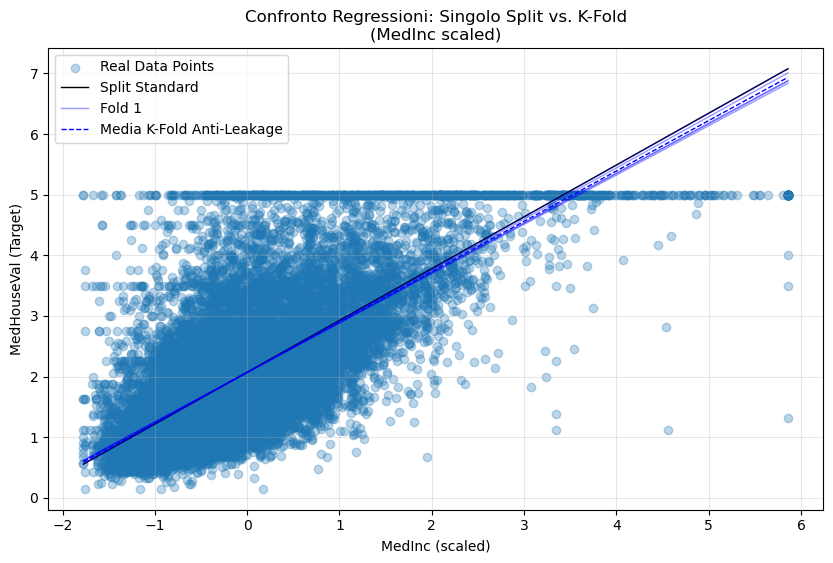

In [21]:
# Ricalcolo dei dati SCALATI per lo Scatter Plot (necessario per l'asse X)
X_plot_feature = StandardScaler().fit_transform(X)[:, feature_index]
y_plot_all = y 

# Coefficienti Split Standard
coef_standard = model_standard.coef_[feature_index]
intercept_standard = model_standard.intercept_

plt.figure(figsize=(10, 6))
# Scatter Plot dei punti reali
plt.scatter(X_plot_feature, y_plot_all, alpha=0.3, label='Real Data Points')
# Range X per tracciare la linea
X_range = np.linspace(X_plot_feature.min(), X_plot_feature.max(), 100)

# Regressione Split Standard
Y_standard = coef_standard * X_range + intercept_standard 
plt.plot(X_range, Y_standard, color='black', linewidth=1, label='Split Standard')

# Regressioni K=5-Fold
for i, coefs in enumerate(kfold_model_coef):
    coef_kfold = coefs[feature_index]
    intercept_kfold = last_model_kfold.intercept_ 
    Y_kfold = coef_kfold * X_range + intercept_kfold 
    
    # Linee individuali dei folds
    plt.plot(X_range, Y_kfold, color='blue', alpha=0.4, linewidth=1, label=f'Fold {i+1}' if i == 0 else "_nolegend_")

# Regressione Media K-Fold
Y_avg_kfold = avg_coef_kfold * X_range + avg_intercept_kfold
plt.plot(X_range, Y_avg_kfold, color='blue', linestyle='--', linewidth=1, label='Media K-Fold Anti-Leakage')

plt.title(f"Confronto Regressioni: Singolo Split vs. K-Fold\n({feature_to_plot} scaled)")
plt.xlabel(f"{feature_to_plot} (scaled)")
plt.ylabel("MedHouseVal (Target)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()